In [ ]:
!pip install pandas numpy seaborn plotly matplotlib scipy scikit-learn xgboost category_encoders catboost lightgbm kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 MB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.3.1+cu121 requires nvidia-cublas-cu12==12.1.3.1; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cuda-cupti-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cuda-nvrtc-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.1+cu121 requires nvidia-cuda-runtime-cu12==12.1.105; platform_syste

In [ ]:
pip install openpyxl

# Task: Efficient shops revenue prediction

Columns description:

1. `TDLinx`: Unique identifier for each retail location.
2. `Type Mag`: Type of retail outlet, e.g., Hypermarché (hypermarket), Magasin Bio (organic store).
3. `Tête de Chaine`: Name of the retail chain or group, if applicable.
4. `Type secondaire`: Secondary type/category of the outlet, if any.
5. `Nom Enseigne`: Name of the store or brand.
6. `Type de contrat`: Contract type, e.g., Intégré (integrated), Indépendant (independent).
7. `DPT`: Department number, similar to a county or regional code in France.
8. `CP`: Postal code of the store location.
9. `Ville`: City where the store is located.
10. `N° Nom de voie`: Street address of the store.
11. `Ca estimé TTC SDV`: Estimated total annual sales including tax, for the store.
12. `CATP Estimé (M€)`: Estimated total annual turnover potential in million Euros.
13. `CATP ESTIME PROXI SDMP C&D ET BIO (JANVIER 2022)`: Estimated proximity sales potential for self-service, convenience, and organic sections as of January 2022.
14. `Surface de vente`: Sales area of the store in square meters.
15. `Complément d'adresse`: Additional address details, if any.
16. `Caisses`: Number of checkout lanes/cash registers.
17. `Carburant (O/N)`: Whether the store has fuel services (Oui/Non).
18. `Places parking`: Number of parking spaces available.
19. `Service drive (O/N)`: Whether the store offers drive-through service (Oui/Non).
20. `Total Employés`: Total number of employees at the store.
21. `Siège National`: National headquarters of the store or chain.
22. `Téléphone`: Phone number of the store.
23. `Fax`: Fax number of the store, if available.
24. `Siret`: A unique French business identification number.
25. `Raison Sociale`: Legal name of the business or corporation.
26. `X (WGS84) and Y (WGS84)`: Global coordinates of the store location based on the WGS84 system.
27. `Date Création`: Date the store was established.
28. `X (Lambert 2) and Y (Lambert 2)`: Coordinates of the store location based on the Lambert II extended system used in France.
29. `Qualification (Lambert 2)`: Describes the accuracy of the store's location based on Lambert II coordinates, e.g., "Repositionné" (repositioned), "Géocodé au n° le + proche" (geocoded to the nearest number).

# Step 1: Libraries import and first data overview

In [ ]:
# general libraries
import pandas as pd
import numpy as np
from typing import List

# visualization libraries
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
#import plotly.io as pio
#pio.renderers.default = "svg"

# ML and clustering libraries
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
from sklearn.inspection import permutation_importance
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV



pd.__version__

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


'2.0.3'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 2022-11-02 Base concurrence.xlsx to 2022-11-02 Base concurrence.xlsx


In [ ]:
df = pd.read_excel("2022-11-02 Base concurrence.xlsx")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
#df = pd.read_excel("/content/drive/MyDrive/Dataset/Nielsen/2022-11-02 Base concurrence.xlsx")

In [ ]:
# # Set pandas options to display all columns
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_info_columns', 100)

# try:
#     df = pd.read_excel("/content/drive/MyDrive/Dataset/Nielsen/2022-11-02 Base concurrence.xlsx")
# except:
#     print("Something went wrong!")

df.head()

### Columns renaming

ML target column = `estimated_annual_sales_ttc`

In [ ]:
# Define the new column names
new_column_names = {
    'TDLinx': 'unique_id',
    'Type Mag': 'retail_type',
    'Tête de Chaine': 'chain_name',
    'Type secondaire': 'secondary_type',
    'Nom Enseigne': 'store_name',
    'Type de contrat': 'contract_type',
    'DPT': 'department_number',
    'CP': 'postal_code',
    'Ville': 'city',
    'N° Nom de voie': 'street_address',
    'Ca estimé TTC SDV ': 'estimated_annual_sales_ttc',
    'CATP Estimé (M€)': 'estimated_annual_turnover_million_euros',
    'CATP ESTIME PROXI SDMP C&D ET BIO (JANVIER 2022)': 'estimated_proximity_sales_potential_jan_2022',
    'Surface de vente': 'sales_area_sqm',
    'Complément d\'adresse': 'additional_address_details',
    'Caisses': 'checkout_lanes',
    'Carburant (O/N)': 'fuel_services',
    'Places parking': 'parking_spaces',
    'Service drive (O/N)': 'drive_through_service',
    'Total Employés': 'total_employees',
    'Siège National': 'national_headquarters',
    'Téléphone': 'phone_number',
    'Fax': 'fax_number',
    'Siret': 'business_id',
    'Raison Sociale': 'legal_name',
    'X (WGS84)': 'x_coord_wgs84',
    'Y (WGS84)': 'y_coord_wgs84',
    'Date Création': 'establishment_date',
    'X (Lambert 2)': 'x_coord_lambert_ii',
    'Y (Lambert 2)': 'y_coord_lambert_ii',
    'Qualification  (Lambert 2)': 'location_accuracy_lambert_ii'
}

# Rename the columns
df.rename(columns=new_column_names, inplace=True)

df.head()

,unique_id,retail_type,chain_name,secondary_type,store_name,contract_type,department_number,postal_code,city,street_address,...,phone_number,fax_number,business_id,legal_name,x_coord_wgs84,y_coord_wgs84,establishment_date,x_coord_lambert_ii,y_coord_lambert_ii,location_accuracy_lambert_ii
0,00406263,Hypermarché,CSF,-,MARKET,Intégré,1.0,1500.0,AMBERIEU EN BUGEY,rue Alexandre Bérard,...,04 74 38 50 19,04 74 38 64 55,4.402838e+13,CSF,5.358915,45.961535,1977-11-16,834232.00,2111314.00,Repositionné
1,07621792,Magasin Bio,NaN,-,LA VIE CLAIRE,Intégré,1.0,1500.0,AMBERIEU EN BUGEY,10 rue des Frères Salvez,...,04 37 61 00 86,NaN,6.320000e+13,LA VIE CLAIRE,5.345318,45.977826,2022-05-01,833102.38,2113081.94,Géocodé au n° le + proche
2,00269720,SDMP,ITM ALIMENTAIRE,-,NETTO,Indépendant,1.0,1500.0,AMBERIEU EN BUGEY,av Léon Blum,...,04 74 46 81 07,04 74 38 65 85,5.130790e+13,AUFRE,5.342419,45.962547,1992-06-22,832942.80,2111376.30,Repositionné
3,04963630,Petit Libre-Service,CASINO DIRECTION PROXIMITE,-,VIVAL,Intégré,1.0,1500.0,AMBERIEU EN BUGEY,71 av Roger Salengro,...,04 74 34 02 07,NaN,NaN,NaN,5.345305,45.955448,2000-07-01,833196.55,2110596.40,Géocodé au n° de voie
4,07262717,SDMP,NaN,-,LIDL,Intégré,1.0,1500.0,AMBERIEU EN BUGEY,70 av de la Libération,...,NaN,NaN,3.432626e+13,LIDL,5.339194,45.966178,2018-02-27,832677.60,2111770.10,Repositionné


### General info about the dataset

In [ ]:
df.info()

### Checking for the nan values in the dataset

In [ ]:
df.isna().sum()

In [ ]:
df.describe()

### Intermediate conclusion

1. The columns were renamed to English. Some names contained spaces that were hard to locate.
2. Columns' types should be oprimized where necessary, e.g. from `object` to `category`, from `float64` to `int` and so on. This will greatly reduce the dataset size and speed up the ML process.
3. There are some redundant columns that should be removed, e.g. `phone_number`, `fax_number`, `business_id`, and so on. I will also remove the `estimated_annual_turnover_million_euros`, and `estimated_proximity_sales_potential_jan_2022` since our target column `estimated_annual_sales_ttc` is simply a sum of these 2 columns.

# Step 2: data preprocessing

### 2.1. Removing of the redundant columns

Replace '-' with 'nan'

In [ ]:
df['secondary_type'].replace('-', np.nan, inplace=True)

In [ ]:
df.isna().sum()

unique_id                                           0
retail_type                                         1
chain_name                                      12039
secondary_type                                  22586
store_name                                          1
contract_type                                       1
department_number                                   1
postal_code                                         1
city                                                1
street_address                                   1993
estimated_annual_sales_ttc                          1
estimated_annual_turnover_million_euros             1
estimated_proximity_sales_potential_jan_2022        0
sales_area_sqm                                      1
additional_address_details                      21094
checkout_lanes                                      1
fuel_services                                       1
parking_spaces                                      1
drive_through_service       

### Years since opening

In [ ]:
# Calculate the number of years passed since the establishment date
current_year = pd.Timestamp.now().year

df['years_opened'] = current_year - df['establishment_date'].dt.year

### Explanation:

There are a lot of useless or redundant columns. I decided to drop them since they will likely not add any value for the quality of prediction. Additionally, in this work I will not use coordinates since I do not have enough time for it. However, this might be considered in the future.

In [ ]:
col_remove = ['phone_number', 'fax_number', 'business_id', 'estimated_annual_turnover_million_euros', 'estimated_proximity_sales_potential_jan_2022',
               'unique_id', 'chain_name', 'legal_name', 'additional_address_details', 'location_accuracy_lambert_ii', 'street_address',
                 'national_headquarters', 'department_number', 'secondary_type', 'establishment_date',
              "store_name"]
df = df.drop(columns=col_remove)

There is a row where a lot of columns are equal to nan, let's look at it.

In [ ]:
# List of columns to check for NaN
columns_to_check = ['estimated_annual_sales_ttc', 'postal_code', 'city'] # 'store_name'

# Look up rows where all specified columns are NaN
rows_with_all_nan = df[df[columns_to_check].isna().all(axis=1)]

# Display the rows with all specified columns as NaN
rows_with_all_nan

,retail_type,contract_type,postal_code,city,estimated_annual_sales_ttc,sales_area_sqm,checkout_lanes,fuel_services,parking_spaces,drive_through_service,total_employees,x_coord_wgs84,y_coord_wgs84,x_coord_lambert_ii,y_coord_lambert_ii,years_opened
28546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Drop this row

In [ ]:
df.drop(rows_with_all_nan.index, inplace=True)

In [ ]:
df.sample(5)

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df.hist(figsize=(20, 10));

### Optimize pandas dtypes

In [ ]:
df.sample(5)

In [ ]:
df['checkout_lanes'] = df['checkout_lanes'].astype(int)
df['parking_spaces'] = df['parking_spaces'].astype(int)
df['total_employees'] = df['total_employees'].astype(int)
df['years_opened'] = df['years_opened'].astype(int)
df['sales_area_sqm'] = df['sales_area_sqm'].astype(int)
df['postal_code'] = df['postal_code'].astype(int)#.astype('category')

### Define a dtypes optimizer functions

In [ ]:
def optimize_floats(df: pd.DataFrame) -> pd.DataFrame:
    floats = df.select_dtypes(include=['float64']).columns.tolist()
    df[floats] = df[floats].apply(pd.to_numeric, downcast='float')
    return df


def optimize_ints(df: pd.DataFrame) -> pd.DataFrame:
    ints = df.select_dtypes(include=['int64']).columns.tolist()
    df[ints] = df[ints].apply(pd.to_numeric, downcast='integer')
    return df


def optimize_objects(df: pd.DataFrame, datetime_features: List[str]) -> pd.DataFrame:
    for col in df.select_dtypes(include=['object']):
        if col not in datetime_features:
            if not (type(df[col][0])==list):
                num_unique_values = len(df[col].unique())
                num_total_values = len(df[col])
                if float(num_unique_values) / num_total_values < 0.5:
                    df[col] = df[col].astype('category')
        else:
            df[col] = pd.to_datetime(df[col])
    return df



def optimize(df: pd.DataFrame, datetime_features: List[str] = []):
    return optimize_floats(optimize_ints(optimize_objects(df, datetime_features)))

In [ ]:
df = optimize(df)

In [ ]:
df.info()

## Feature engineering

### Apply the Huff Model store attractiveness score

In [ ]:
def calculate_attractiveness(df):
    # Normalize store attributes by dividing by their max values
    norm_factors = df[['sales_area_sqm', 'parking_spaces', 'checkout_lanes']] / df[['sales_area_sqm', 'parking_spaces', 'checkout_lanes']].max()

    # Calculate weighted attractiveness using given weights
    weights = np.array([0.5, 0.3, 0.5])
    df['attractiveness'] = norm_factors.dot(weights)

    return df

def calculate_distances(df):
    # Initialize an empty DataFrame for distances
    distances = pd.DataFrame(index=df.index, columns=df.index)

    for city in df['city'].unique():
        # Get data for the current city
        city_group = df[df['city'] == city]
        coords = city_group[['x_coord_wgs84', 'y_coord_wgs84']].values

        # Calculate pairwise distances within the city using Euclidean distance
        city_distances = pdist(coords)
        city_distances = squareform(city_distances)

        # Populate the distance matrix
        for j, idx1 in enumerate(city_group.index):
            for k, idx2 in enumerate(city_group.index):
                if j != k:
                    distances.at[idx1, idx2] = city_distances[j, k]
                else:
                    distances.at[idx1, idx2] = np.nan  # Assign NaN to self-distances

    return distances

def huff_model(df):
    # Calculate store attractiveness
    df = calculate_attractiveness(df)
    # Calculate distances within the same city
    distances = calculate_distances(df)

    # Initialize Huff attractiveness column
    df['huff_attr'] = 0.0

    for city in df['city'].unique():
        # Get data for the current city
        city_group = df[df['city'] == city]
        city_indices = city_group.index
        city_distances = distances.loc[city_indices, city_indices]
        city_attractiveness = city_group['attractiveness']

        # Calculate probabilities using Huff model
        epsilon = 1e-10  # Small constant to avoid division by zero
        probs = city_attractiveness.values / ((city_distances.values + epsilon) ** 2)
        np.fill_diagonal(probs, 0)  # Exclude self-visits

        # Normalize probabilities
        row_sums = probs.sum(axis=1)
        row_sums[row_sums == 0] = 1  # Avoid division by zero
        probs = probs / row_sums[:, np.newaxis]

        # Sum probabilities to get Huff attractiveness
        huff_attr = probs.sum(axis=0)
        df.loc[city_indices, 'huff_attr'] = huff_attr

    # Drop intermediate attractiveness column
    df.drop(columns=['attractiveness'], inplace=True)

    # Change the target column dtype
    df['huff_attr'] = df['huff_attr'].astype('float32')

    # Huff model score normalization
    #df['huff_attr'] = df['huff_attr'].max()

    return df

# Apply the Huff Model to the DataFrame
df = huff_model(df)

In [ ]:
df.head()

### Intermediate conclusion:
1. Redundant columns were deleted.
2. Pandas dtypes were optimized.
3. Nan values were removed or cleaned.
4. Dtype optimization and redundant columns deletion has helped to reduce memory consumption from 6.8+ MB to 1.0 MB (almost 7 times).
5. It looks like the dataset doesn't contain significant outlier from the presented histograms.

# Step 3: Explorative Data Analysis (EDA)

### Feature correlations

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['estimated_annual_sales_ttc', 'sales_area_sqm', 'checkout_lanes', 'parking_spaces', 'total_employees', 'years_opened', 'huff_attr']].corr(), cmap='Blues', annot=True)
plt.title('Features correlations', size=20)
plt.show()

In [ ]:
column_names = ['sales_area_sqm', 'checkout_lanes', 'parking_spaces', 'total_employees', 'years_opened', 'huff_attr']

# Define the number of rows and columns for the subplot grid
n_rows = 3
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 20))

# Flatten the array of axes to make iterating easier
axs = axs.flatten()

# Loop through the column names and create a scatter plot in each subplot
for i, column in enumerate(column_names):
    axs[i].scatter(df[column], df['estimated_annual_sales_ttc'], alpha=0.03)
    axs[i].set_title(f'Scatter plot of {column} vs. annual_sales')
    axs[i].grid(True)

plt.tight_layout()

# Show the plot
plt.show()

As we can see from the correlation heatmap, there is a strong positive correlation between the size of a store and its revenue. However, this might be a bit misleading, since our dataset contains only the stores that are currently working and generating value.
Additionally, we can see that some postal codes definitely generate more value than the other ones and there is some impact of the `years_opened` column on the estimated annual sales (the shops that generate the most sales were opened between 25 and 60 years ago).

# Further feature engineering is required!

The correlations between the annual sales and other features may be misleading. It would be great to find some library like `https://pypi.org/project/uszipcode/` but for Europe or France particularly. Or some other dataset with this cind of info. Some nice features to include to the datasrt would be:
1. Land area in km-sq.
2. Water area in km-sq.
3. Border polygon.
4. Population.
5. Population density.
6. Median household income.
7. Number of tourists per year.
8. Source of earnings (tourism, industry, etc.).
9. Population projection into the future.
10. Crime rate.
11. Inflation rate.
12. Average annual sunshine (hours).
13. Average annual rainfall (mm).
14. Average annual temperature.

Some sources for the future:
1. https://ec.europa.eu/eurostat/web/population-demography/demography-population-stock-balance/database
2. https://ec.europa.eu/eurostat/cache/digpub/regions/#gross-domestic-product
3. https://ec.europa.eu/eurostat/data/database
4. https://data.europa.eu/data/datasets?locale=en&hvdCategory=c_e1da4e07&page=1&dataScope=countryData&country=fr
5. https://www.kaggle.com/datasets/benoitfavier/immobilier-france
6. https://www.kaggle.com/datasets/gatandubuc/public-transport-traffic-data-in-france
7. https://www.data.gouv.fr/fr/datasets/
8. https://github.com/zakariakhodrium/french_cities
9. https://www.kaggle.com/datasets/etiennelq/french-employment-by-town
10. https://data.europa.eu/data/datasets/5b156279c751df40bb588de9?locale=en
11. https://data.europa.eu/data/datasets/53699324a3a729239d2040e9?locale=en
12. https://data.europa.eu/data/datasets/f3ec08edc7d6489faf8c1c9f9b6f73ee?locale=en



# Stores localtions

In [ ]:
# Define color scale (optional customization)
color_scale = [(0, 'orange'), (1, 'red')]

# Create the scatter mapbox plot
fig = px.scatter_mapbox(df,
                        lat="y_coord_wgs84",
                        lon="x_coord_wgs84",
                        color_continuous_scale=color_scale,
                        zoom=6,
                        height=1600,
                        width=1600)

# Update the layout to use OpenStreetMap and remove margins
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":0, "l":0, "b":0})

# Update marker size
fig.update_traces(marker=dict(size=3))

# Show the plot
fig.show()

# Areas that generate the most sales

In [ ]:
# Drop rows with NaN values in the coordinates
df = df.dropna(subset=['x_coord_wgs84', 'y_coord_wgs84'])

# Extract coordinates for clustering
coords = df[['x_coord_wgs84', 'y_coord_wgs84']].values

# Define number of clusters
num_clusters = 1000  # Set the desired number of clusters

# Perform K-Means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init='auto').fit(coords)
df['cluster'] = kmeans.labels_

# Aggregate sales data by cluster
aggregated_sales = df.groupby('cluster').agg(
    total_sales=('estimated_annual_sales_ttc', 'sum'),
    x_coord=('x_coord_wgs84', 'mean'),
    y_coord=('y_coord_wgs84', 'mean')
).reset_index()

# Define color scale (optional customization)
color_scale = [(0, 'orange'), (1, 'red')]

# Create the scatter mapbox plot
fig = px.scatter_mapbox(aggregated_sales,
                        lat="y_coord",
                        lon="x_coord",
                        size='total_sales',
                        color='total_sales',
                        color_continuous_scale=color_scale,
                        zoom=6,
                        height=1600,
                        width=1600,
                        title='Clustered Locations with Summed Estimated Annual Sales')

# Update the layout to use OpenStreetMap and remove margins
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":0, "l":0, "b":0})

# Show the plot
fig.show()

# Drop the cluster column
df.drop(columns='cluster', inplace=True)

## Total sales per city

In [ ]:
grouped_sales_city = df.groupby(['city'])['estimated_annual_sales_ttc'].sum().to_frame().reset_index().sort_values('estimated_annual_sales_ttc', ascending=False).head(20)

In [ ]:
fig = px.bar(grouped_sales_city, x='city', y='estimated_annual_sales_ttc', text_auto='.3s', labels={'estimated_annual_sales_ttc': 'Total Sales [mln €]', 'city': 'City'}, width=1500, height=800)
fig.update_layout(title={
        'text': 'Total sales per city (Top-20 results)',
        'y':0.96,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font_size': 32
    })
fig.show()

## Total sales per postal code

In [ ]:
grouped_sales_zip = df.groupby(['city', 'postal_code'])['estimated_annual_sales_ttc'].sum().to_frame().reset_index().sort_values('estimated_annual_sales_ttc', ascending=False).head(20)

In [ ]:
fig = px.bar(grouped_sales_zip, x='city', y='estimated_annual_sales_ttc', text_auto='.3s', labels={'estimated_annual_sales_ttc': 'Total Sales [mln €]', 'city': 'City'}, width=1500, height=800)
fig.update_layout(title={
        'text': 'Total sales per postal-code (Top-20 results)',
        'y':0.96,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font_size': 32
    })
fig.show()

## Sales share analysis per Retail type and Contract type

In [ ]:
# Create subplots: 1 row, 2 columns, specify 'domain' type for pie charts
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=("Sales Share per Retail Type", "Sales Share per Contract Type")
)

# Define common color mapping for both charts
color_mapping = px.colors.qualitative.Pastel

# Create first pie chart with common color mapping
fig1 = go.Pie(labels=df['retail_type'],
              values=df['estimated_annual_sales_ttc'],
              hole=0.4,
              marker=dict(colors=color_mapping),
              textinfo='label+percent')

# Create second pie chart with common color mapping
fig2 = go.Pie(labels=df['contract_type'],
              values=df['estimated_annual_sales_ttc'],
              hole=0.4,
              marker=dict(colors=color_mapping),
              textinfo='label+percent')

# Add traces to the subplots
fig.add_trace(fig1, row=1, col=1)
fig.add_trace(fig2, row=1, col=2)

# Update layout for the overall figure
fig.update_layout(
    title={
        'text': "Sales Share Analysis",
        'y':0.95,  # Vertical alignment
        'x':0.5,   # Horizontal alignment
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}
    },
    width=1600,
    height=800,
    showlegend=False,
    annotations=[
        dict(text="Retail Type", x=0.22, y=0.48, font_size=20, showarrow=False),
        dict(text="Contract Type", x=0.78, y=0.48, font_size=20, showarrow=False)
    ]
)

# Show plot
fig.show()

# Step 4: Data preparation for the ML part

## 4.1 Create helper functions
### Function: data_splitter()
Split our dataset in parts. We will use cross-validation, that is why we do not need a separate validation dataset.

* Train: 80%
* Test: 20% (to test the final model)

In [ ]:
def data_splitter(data, testSize = 0.2):

    # splitting the train-test data
    train, test = train_test_split(data, test_size=testSize, random_state=42)

    # assigning features and targets for train and test samples
    X_train = train.drop('estimated_annual_sales_ttc', axis=1)
    y_train = train['estimated_annual_sales_ttc']

    X_test = test.drop('estimated_annual_sales_ttc', axis=1)
    y_test = test['estimated_annual_sales_ttc']

    print('X_train: {0} ({1}%)'.format(X_train.shape[0], (X_train.shape[0]/data.shape[0])*100))
    print('y_train: {0} ({1}%)'.format(y_train.shape[0], (y_train.shape[0]/data.shape[0])*100))
    print()
    print('X_test: {0} ({1}%)'.format(X_test.shape[0], (X_test.shape[0]/data.shape[0])*100))
    print('y_test: {0} ({1}%)'.format(y_test.shape[0], (y_test.shape[0]/data.shape[0])*100))

    return X_train, y_train, X_test, y_test

### Function: plot_real_vs_pred()
Plotting real and predicted data.

In [ ]:
def plot_real_vs_pred(model_name, y_real, y_pred):
    plt.style.use('ggplot')
    reg_real_vs_pred = pd.DataFrame({'Actual': y_real, 'Predicted': y_pred})
    reg_real_vs_pred = reg_real_vs_pred.head(40)
    reg_real_vs_pred.plot(kind='bar', title='MODEL: '+model_name, figsize=(18,5))
    plt.show()

### Function: basemodel_predict()
Get predictions of the baseline model, it will make average sales predictions based on the postal code.

In [ ]:
def basemodel_predict(base, X_test):
    # Prepare the output array
    output = []

    # Calculate the average estimated sales for each postal code
    base_averages = base.groupby('postal_code')['estimated_annual_sales_ttc'].mean().reset_index()

    # Calculate the overall average sales (used as a fallback)
    overall_average = base['estimated_annual_sales_ttc'].mean()

    # Iterate through the test set
    for index, row in X_test.iterrows():
        # Fetch the average sales for the current postal code
        avg_sales = base_averages[base_averages['postal_code'] == row['postal_code']]['estimated_annual_sales_ttc'].values

        if len(avg_sales) > 0:
            # If we have data for this postal code, use it
            output.append(avg_sales[0])
        else:
            # If no data for this postal code, use the overall average
            output.append(overall_average)

    return np.array(output)

### Function: get_metrics()
Function to calculate all relevant metrics.

* Inputs: model name, real target values, predicted values.
* Outputs: model name, MAE.

In [ ]:
def get_metrics(model_name, y_real, y_pred):
    # MAE: same units as target variable. It is more robust to outliers
    MAE = mean_absolute_error(y_real, y_pred)

    print(f'MODEL: {model_name}')
    print(f'MAE: {MAE:.2f}')  # Use string formatting to display 2 decimal places

    return model_name, MAE

### Function: compare_model_metrics()
Given a list of 'model_metrics', obtained from the function get_metrics(), this function creates several bar plots to compare metrics from different models and choose the best one

In [ ]:
def compare_model_metrics(mod_metric_list):
    plt.style.use('ggplot')

    # Initialize empty DataFrame for MAE
    df_MAE = pd.DataFrame(columns=['MAE'])

    # List to store DataFrame entries before concatenating
    entries_MAE = []

    # Populate entries for MAE
    for mod in mod_metric_list:
        entries_MAE.append({'MAE': mod[1]})

    # Convert list to DataFrame
    df_MAE = pd.DataFrame(entries_MAE, index=[mod[0] for mod in mod_metric_list])

    # Sort DataFrame
    df_MAE.sort_values('MAE', ascending=True, inplace=True)

    # Plotting
    f, ax = plt.subplots(figsize=(8, len(mod_metric_list) * 0.75))
    df_MAE.plot(kind='barh', ax=ax, color='lightcoral', title='Model Comparison - MAE', legend=False)

    # Annotate each bar in the plot
    for p in ax.patches:
        ax.annotate(format(p.get_width(), '.2f'),
                    (p.get_x() + p.get_width(), p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords='offset points', ha='left', va='center')

    plt.tight_layout()
    plt.show()

### Function: plot_3d_mae

The function plot a 3D MAE chart to see the relationship between the number of estimators and the learning rate.

In [ ]:
def plot_3d_mae(model_name, results_df, best_params):
    """
    Function to plot a 3D scatter plot of MAE with given parameters.

    Parameters:
    - results_df: DataFrame containing the results of GridSearchCV.
    - best_params: Dictionary of best parameters obtained from GridSearchCV.

    Returns:
    - fig: Plotly Figure object.
    """
    # Find the best parameters
    best_n_estimators = best_params['n_estimators']
    best_learning_rate = best_params['learning_rate']

    # Create a 3D plot with Plotly
    fig = px.scatter_3d(
        results_df,
        x='n_estimators',
        y='learning_rate',
        z='MAE',
        color='MAE',
        title=f'{model_name}: 3D Visualization of averaged Cross-Validation MAE',
        labels={'n_estimators': 'Number of Estimators', 'learning_rate': 'Learning Rate', 'MAE': 'Mean Absolute Error'}
    )

    # Highlight the best parameter combination
    fig.add_scatter3d(
        x=[best_n_estimators],
        y=[best_learning_rate],
        z=[results_df[(results_df['n_estimators'] == best_n_estimators) &
                         (results_df['learning_rate'] == best_learning_rate)]['MAE'].values[0]],
        mode='markers',
        marker=dict(size=10, color='red', symbol='diamond'),
        name='Best Parameters'
    )

    # Update layout: move title to the center and remove color bar
    fig.update_layout(
        title={
            'text': f'{model_name}: 3D Visualization of Cross-Validation MAE',
            'y': 0.95,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top'
        },
        scene=dict(
            xaxis_title='Number of Estimators',
            yaxis_title='Learning Rate',
            zaxis_title='Mean Absolute Error'
        ),
        coloraxis_showscale=False,  # Remove the color bar
        showlegend=True
    )

    return fig

### Function: grid_model_evaluation()

Applies GridSearchCV with defined parameters and returns the results of the testing.

In [ ]:
def grid_model_evaluation(model, model_name, param_grid, X_train, y_train, X_test, y_test, top_n=10, cv=5):
    """
    Function to evaluate a machine learning model using GridSearchCV and plot the results.

    Parameters:
    - model: The machine learning model to evaluate.
    - model_name: The name of the model.
    - param_grid: The grid of hyperparameters to search.
    - X_train: Training data features.
    - y_train: Training data target.
    - X_test: Testing data features.
    - y_test: Testing data target.
    - top_n: Number of top configurations to display (default is 10).

    Returns:
    - best_model: The best model found by GridSearchCV.
    - best_params: The best hyperparameters found by GridSearchCV.
    - grid_result_df: DataFrame containing the GridSearchCV results.
    - best_cv_score: Best cross-validation MAE.
    - test_mae: MAE on the test set.
    """
    # Set up GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='neg_mean_absolute_error',
        verbose=0,
        n_jobs=-1
    )

    # Fit GridSearchCV
    grid_search.fit(X_train, y_train)

    # Get the best model and its parameters
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # Create a dataframe with all results
    grid_result_df = pd.DataFrame(grid_search.cv_results_)

    # Use .loc to avoid SettingWithCopyWarning
    grid_result_df = grid_result_df.loc[:, ['param_n_estimators', 'param_learning_rate', 'mean_test_score']]
    grid_result_df.loc[:, 'MAE'] = -grid_result_df['mean_test_score']  # Convert to positive MAE
    grid_result_df = grid_result_df.rename(columns={'param_n_estimators': 'n_estimators', 'param_learning_rate': 'learning_rate'})
    grid_result_df = grid_result_df.drop(columns=['mean_test_score'])
    grid_result_df.loc[:, 'MAE'] = grid_result_df['MAE'].round(2)

    # Print best parameters
    print(f"Best Model Parameters: {best_params}")

    # Get predictions of the best model
    y_pred = best_model.predict(X_test)

    # Evaluate the best model
    metrics = get_metrics(model_name, y_test, y_pred)

    # Sort and display the top N results
    print("\nTop {} configurations:".format(top_n))
    print(grid_result_df.sort_values('MAE').head(top_n))

    # Get the cross-validation score for the best parameters
    best_cv_score = -grid_search.best_score_  # Convert back to positive MAE
    print(f"Best averaged cross-validation MAE: {best_cv_score:.2f}")

    # Evaluate on the test set
    test_pred = best_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)
    print(f"Test set MAE: {test_mae:.2f}")

    return best_model, best_params, grid_result_df, best_cv_score, test_mae

## Drop unnecessary columns

The coordinate columns and number of employees will be dropped since coordinates do not generate any value in this dataset, and the number of employees is likely to be unknown by the client.

In [ ]:
df.drop(columns=['x_coord_wgs84', 'y_coord_wgs84', 'x_coord_lambert_ii', 'y_coord_lambert_ii', 'total_employees'], inplace=True)

## Split the data

In [ ]:
X_train, y_train, X_test, y_test = data_splitter(df)

X_train: 22836 (79.99719750578015%)
y_train: 22836 (79.99719750578015%)

X_test: 5710 (20.002802494219857%)
y_test: 5710 (20.002802494219857%)


In [ ]:
X_train

,retail_type,contract_type,postal_code,city,sales_area_sqm,checkout_lanes,fuel_services,parking_spaces,drive_through_service,years_opened
13010,Hypermarché,Intégré,50470,CHERBOURG EN COTENTIN,11890,34,Oui,1500,Non,35
729,Superette,Indépendant,4330,BARREME,100,1,Non,0,Non,38
313,SDMP,Intégré,2220,BRAINE,880,3,Non,90,Non,16
7589,Superette,Indépendant,31600,MURET,179,2,Non,0,Non,11
15496,Petit Libre-Service,Indépendant,59800,LILLE,92,1,Non,0,Non,21
...,...,...,...,...,...,...,...,...,...,...
21575,Superette,Indépendant,75012,PARIS,100,1,Non,0,Non,2
5390,Petit Libre-Service,Indépendant,23000,ST LAURENT,91,1,Non,0,Non,9
860,SDMP,Intégré,5100,BRIANCON,990,4,Non,0,Non,3
15795,SDMP,Intégré,59114,TERDEGHEM,859,5,Non,77,Non,22


In [ ]:
unique_values = {}
for column in df.columns:
    unique_values[column] = df[column].unique().tolist()

with open('unique_values.json', 'w', encoding='utf-8') as f:
    json.dump(unique_values, f, indent=4, ensure_ascii=False)

# Step 5: the ML part
This task is a regression problem.

For our research we will use Gradient-Boosted Decision Trees (GBDT), and XGBoost (eXtreme Gradient Boosting) models together with MAE (mean absolute error), metric since it has shown good results for the similar task, according to this article. Random Forest Regressor will also be used since it often gives decent results from my experience. Additionally, we will also use Linear Regression as one of the most simples approaches and the data has a lot of linear features.

## 5.1 Baseline Model
Let's take an average sales estimation per postal code as our baseline model. This will help us later to check the sanity of other models that we have trained.

In [ ]:
baseline_model = df.groupby(['postal_code'])['estimated_annual_sales_ttc'].mean().round(1)

baseline_model = baseline_model.reset_index()

### Baseline model predictions

In [ ]:
%time
base_y_pred = basemodel_predict(baseline_model, X_test)
print(base_y_pred)

CPU times: user 4 µs, sys: 1e+03 ns, total: 5 µs
Wall time: 8.34 µs
[0.7 4.1 4.5 ... 8.4 3.3 1.4]


### Get metrics and plot Actual vs Predicted value

MODEL: Baseline Model
MAE: 6.78


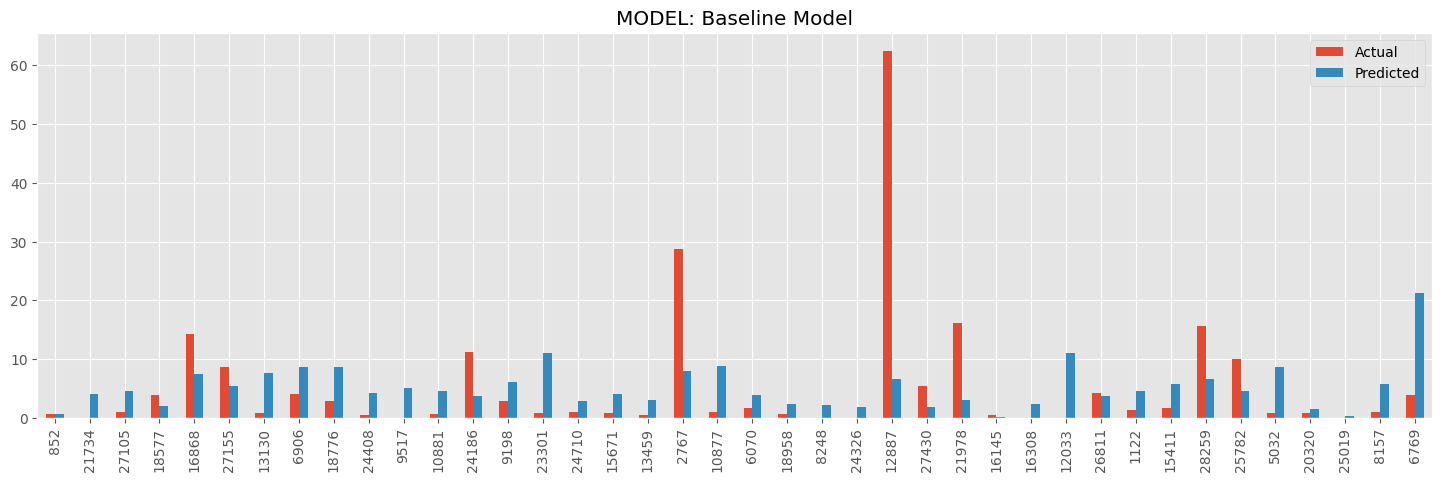

In [ ]:
base_metrics = get_metrics('Baseline Model',y_test, base_y_pred)

plot_real_vs_pred('Baseline Model', y_test, base_y_pred)

### Baseline model conclusion:

The baseline model that is based on average store sales per postal code gives us MAE (mean average error) = 6.67 [mln €]

## 5.2 Linear Regressor model

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Assuming you have a pipeline that includes binary encoding, imputation, data normalization, and the linear regression model.
pipeline = Pipeline([
    ('encoder', ce.BinaryEncoder(cols=categorical_cols, return_df=True)),
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])


# Fit the pipeline on the raw training data
pipeline.fit(X_train, y_train)

# Predict using the pipeline on the raw test data
lin_reg_y_pred = pipeline.predict(X_test)

MODEL: Linear Regression
MAE: 2.41


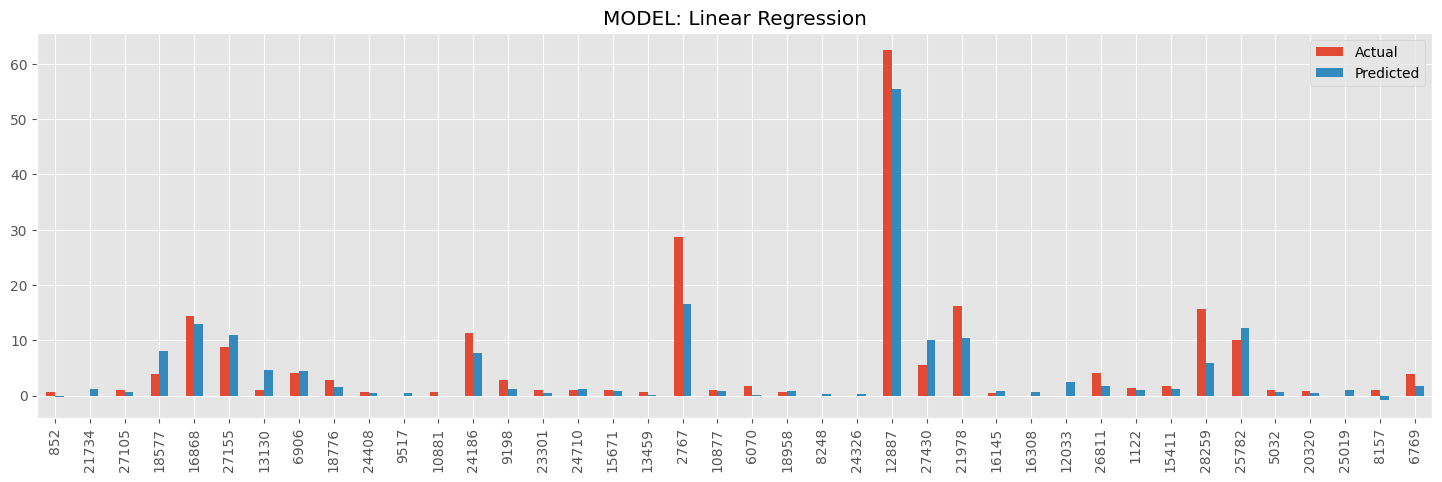

In [ ]:
model_name = 'Linear Regression'

linear_metrics = get_metrics(model_name, y_test, lin_reg_y_pred)

plot_real_vs_pred('Linear Regression', y_test, lin_reg_y_pred)

### Linear model conclusion:

The Linear Regression model has performed way better in comparison to the baseline model, and has given us MAE (mean average error) = 2.25 [mln €], that is around 2.5 times smaller error. However, in some cases where actual sales are pretty low, the model predicts negative sales.

## 5.3 XGBoost (eXtreme Gradient Boosting)

In [ ]:
# Set up the hyperparameters to try
param_grid = {
    'n_estimators': [150],
    'learning_rate': [0.1]
}

# Define a model
xgb_model = XGBRegressor(random_state=42, enable_categorical=True, tree_method='hist',device="cuda") # added tree_method & device

# Test the model and get the results
xgb_best_model, xgb_best_params, xgb_result_df, xgb_best_cv_score, xgb_test_mae = grid_model_evaluation(
    xgb_model, 'XGBoost', param_grid, X_train, y_train, X_test, y_test
)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning:

[14:25:18] WARNING: /workspace/src/context.cc:44: No visible GPU is found, setting device to CPU.



Best Model Parameters: {'learning_rate': 0.1, 'n_estimators': 150}
MODEL: XGBoost
MAE: 2.16

Top 10 configurations:
  n_estimators learning_rate   MAE
0          150           0.1  2.05
Best averaged cross-validation MAE: 2.05
Test set MAE: 2.16


In [ ]:
xgb_y_pred = xgb_best_model.predict(X_test)

xgb_metrics = get_metrics('XGBoost',y_test, xgb_y_pred)

MODEL: XGBoost
MAE: 2.16


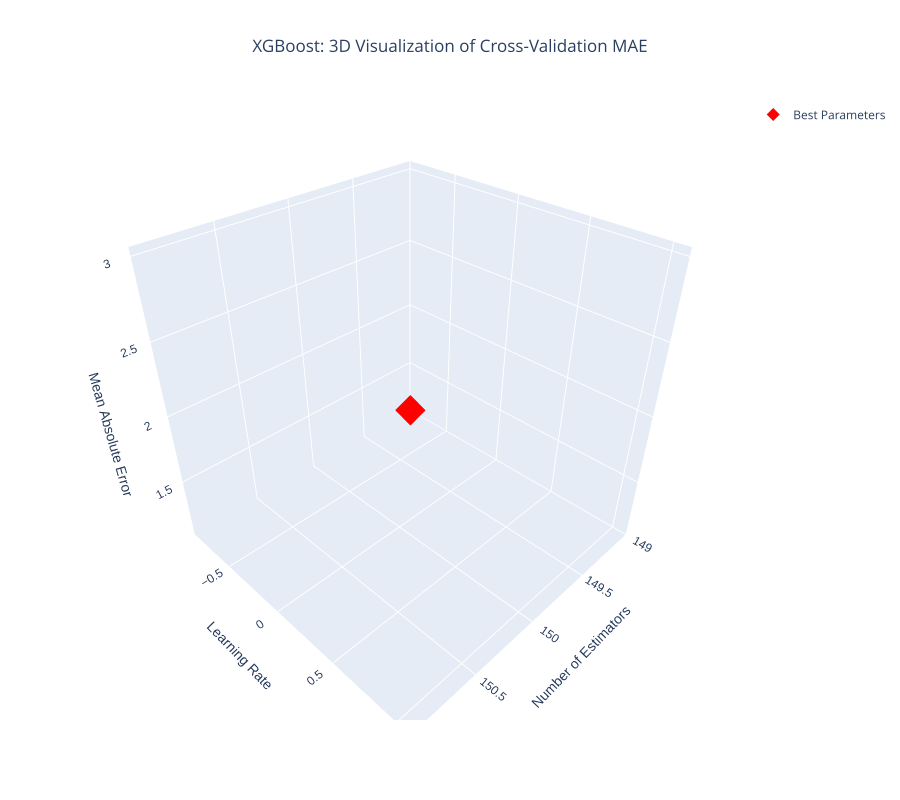

In [ ]:
fig = plot_3d_mae('XGBoost', xgb_result_df, xgb_best_params)
fig.show(renderer="svg", width=900, height=800)

MODEL: XGBoost
MAE: 2.16


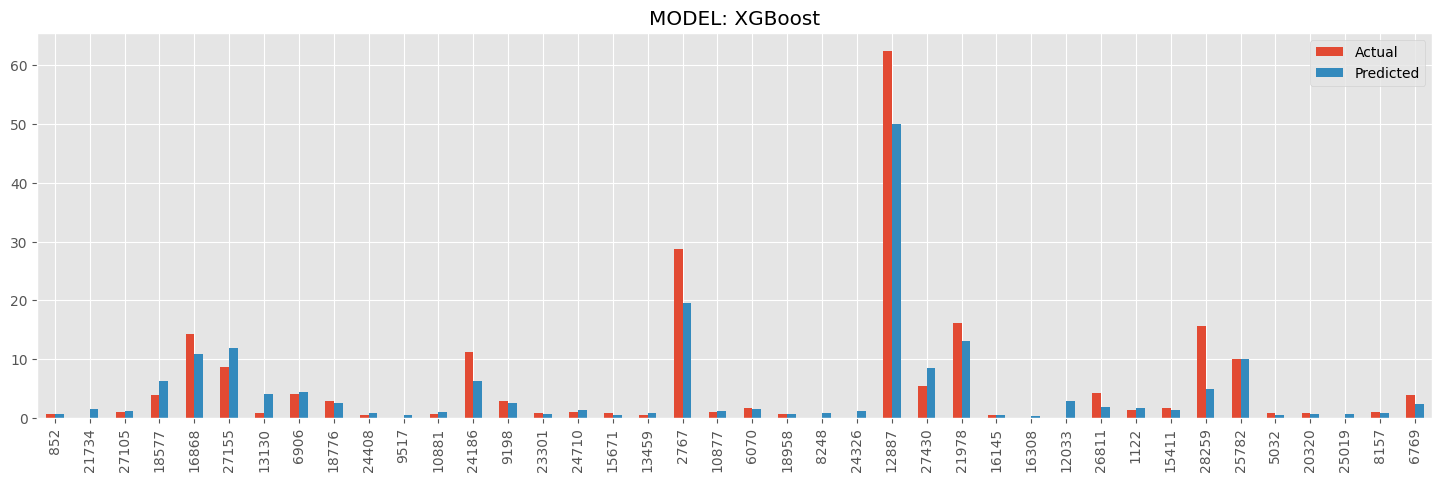

In [ ]:
model_name = 'XGBoost'

xgb_metrics = get_metrics(model_name ,y_test, xgb_y_pred)

plot_real_vs_pred(model_name, y_test, xgb_y_pred)

## 5.4 CatBoost

In [ ]:
# Select only categorical columns
categorical_columns = df.select_dtypes(include=['category']).columns.tolist()

# Set up the hyperparameters to try
param_grid = {
    'n_estimators': [600],
    'learning_rate': [0.1]
}

# Define a model
cat_model = CatBoostRegressor(random_state=42, verbose=3, thread_count=-1, cat_features=categorical_columns) # added task_type GPU

# Test the model and get the results
cat_best_model, cat_best_params, cat_result_df, cat_best_cv_score, cat_test_mae = grid_model_evaluation(
    cat_model, 'CatBoost', param_grid, X_train, y_train, X_test, y_test, cv=10)

0:	learn: 12.4866134	total: 66.7ms	remaining: 40s
3:	learn: 9.8012585	total: 122ms	remaining: 18.2s
6:	learn: 7.8964806	total: 171ms	remaining: 14.5s
9:	learn: 6.5366857	total: 226ms	remaining: 13.3s
12:	learn: 5.6282740	total: 270ms	remaining: 12.2s
15:	learn: 5.0245105	total: 318ms	remaining: 11.6s
18:	learn: 4.6272710	total: 366ms	remaining: 11.2s
21:	learn: 4.3541565	total: 415ms	remaining: 10.9s
24:	learn: 4.1882754	total: 486ms	remaining: 11.2s
27:	learn: 4.0529178	total: 533ms	remaining: 10.9s
30:	learn: 3.9573274	total: 579ms	remaining: 10.6s
33:	learn: 3.8894775	total: 630ms	remaining: 10.5s
36:	learn: 3.8467573	total: 676ms	remaining: 10.3s
39:	learn: 3.7990585	total: 723ms	remaining: 10.1s
42:	learn: 3.7660157	total: 775ms	remaining: 10s
45:	learn: 3.7323124	total: 821ms	remaining: 9.89s
48:	learn: 3.7070673	total: 864ms	remaining: 9.71s
51:	learn: 3.6886074	total: 907ms	remaining: 9.56s
54:	learn: 3.6691066	total: 956ms	remaining: 9.47s
57:	learn: 3.6518537	total: 998ms	rem

In [ ]:
cat_best_model.save_model('cat_best_model.cbm')

In [ ]:
cat_y_pred = cat_best_model.predict(X_test)

cat_metrics = get_metrics('CatBoost',y_test, cat_y_pred)

MODEL: CatBoost
MAE: 1.62


In [ ]:
X_train

,retail_type,contract_type,postal_code,city,sales_area_sqm,checkout_lanes,fuel_services,parking_spaces,drive_through_service,years_opened
13010,Hypermarché,Intégré,50470,CHERBOURG EN COTENTIN,11890,34,Oui,1500,Non,35
729,Superette,Indépendant,4330,BARREME,100,1,Non,0,Non,38
313,SDMP,Intégré,2220,BRAINE,880,3,Non,90,Non,16
7589,Superette,Indépendant,31600,MURET,179,2,Non,0,Non,11
15496,Petit Libre-Service,Indépendant,59800,LILLE,92,1,Non,0,Non,21
...,...,...,...,...,...,...,...,...,...,...
21575,Superette,Indépendant,75012,PARIS,100,1,Non,0,Non,2
5390,Petit Libre-Service,Indépendant,23000,ST LAURENT,91,1,Non,0,Non,9
860,SDMP,Intégré,5100,BRIANCON,990,4,Non,0,Non,3
15795,SDMP,Intégré,59114,TERDEGHEM,859,5,Non,77,Non,22


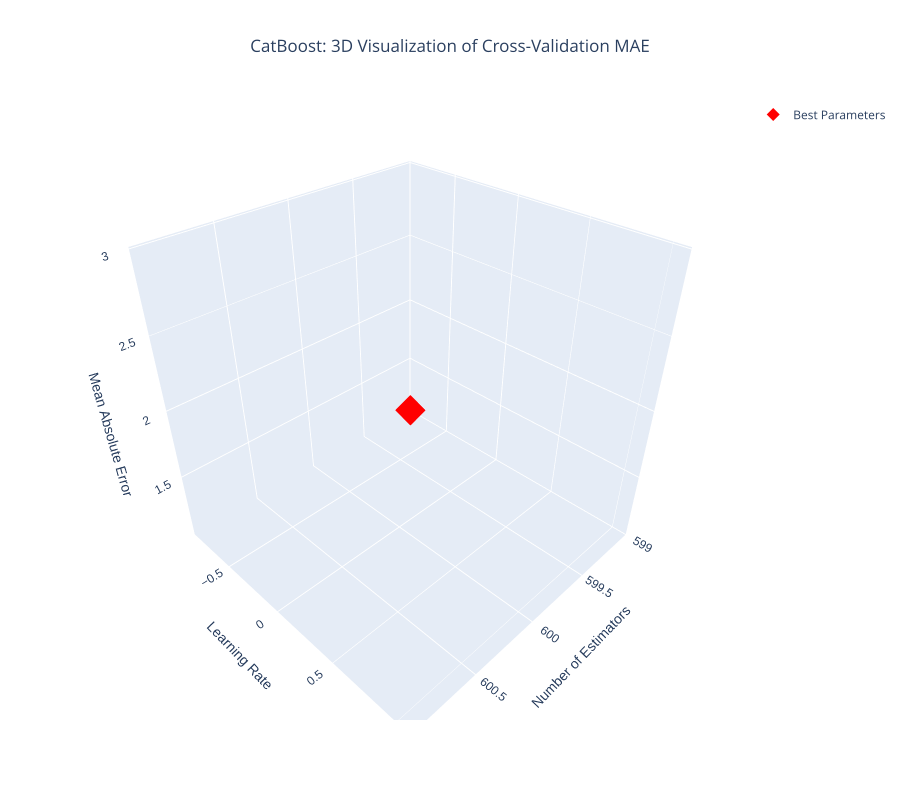

In [ ]:
fig = plot_3d_mae('CatBoost', cat_result_df, cat_best_params)
fig.show(renderer="svg", width=900, height=800)

MODEL: CatBoost
MAE: 1.62


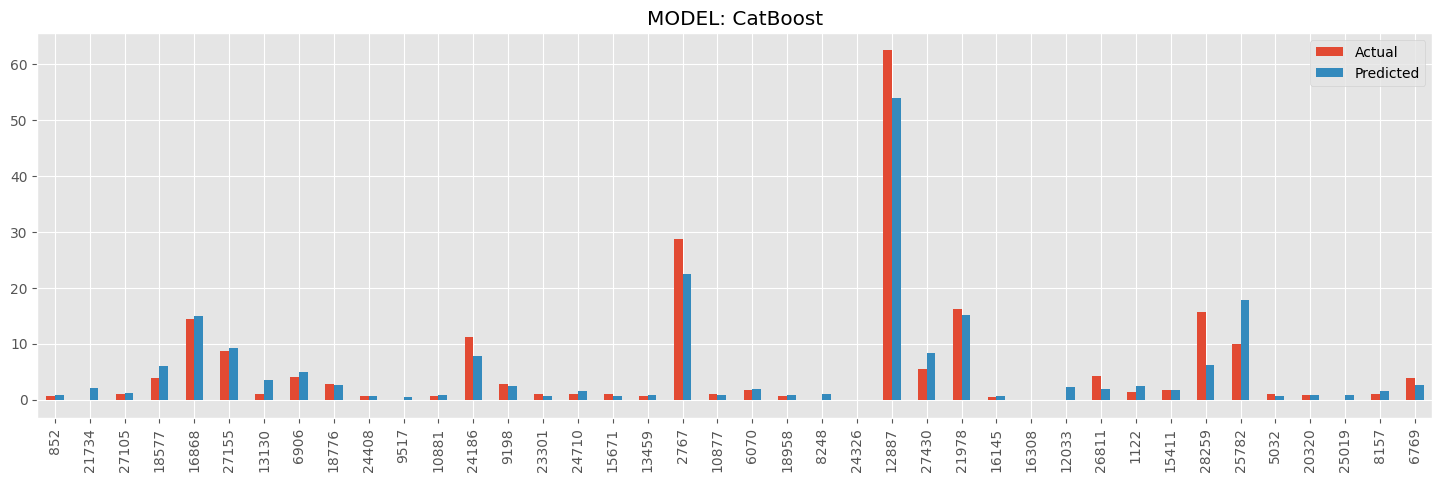

In [ ]:
model_name = 'CatBoost'

cat_metrics = get_metrics(model_name ,y_test, cat_y_pred)

plot_real_vs_pred(model_name, y_test, cat_y_pred)

## 5.5 LightGBM

In [ ]:
# Set up the hyperparameters to try
param_grid_lgbm = {
    'n_estimators': [800],
    'learning_rate': [0.05]
}

# Define a model
lgbm_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, force_row_wise=True, verbose=-1, categorical_cols=categorical_columns)

# Test the model and get the results
lgbm_best_model, lgbm_best_params, lgbm_result_df, lgbm_best_cv_score, lgbm_test_mae = grid_model_evaluation(
    lgbm_model, 'LightGBM', param_grid_lgbm, X_train, y_train, X_test, y_test, cv=5)

Best Model Parameters: {'learning_rate': 0.05, 'n_estimators': 800}
MODEL: LightGBM
MAE: 2.15

Top 10 configurations:
  n_estimators learning_rate   MAE
0          800          0.05  2.07
Best averaged cross-validation MAE: 2.07
Test set MAE: 2.15


In [ ]:
lgbm_y_pred = lgbm_best_model.predict(X_test)

lgbm_metrics = get_metrics('LightGBM',y_test, lgbm_y_pred)

MODEL: LightGBM
MAE: 2.15


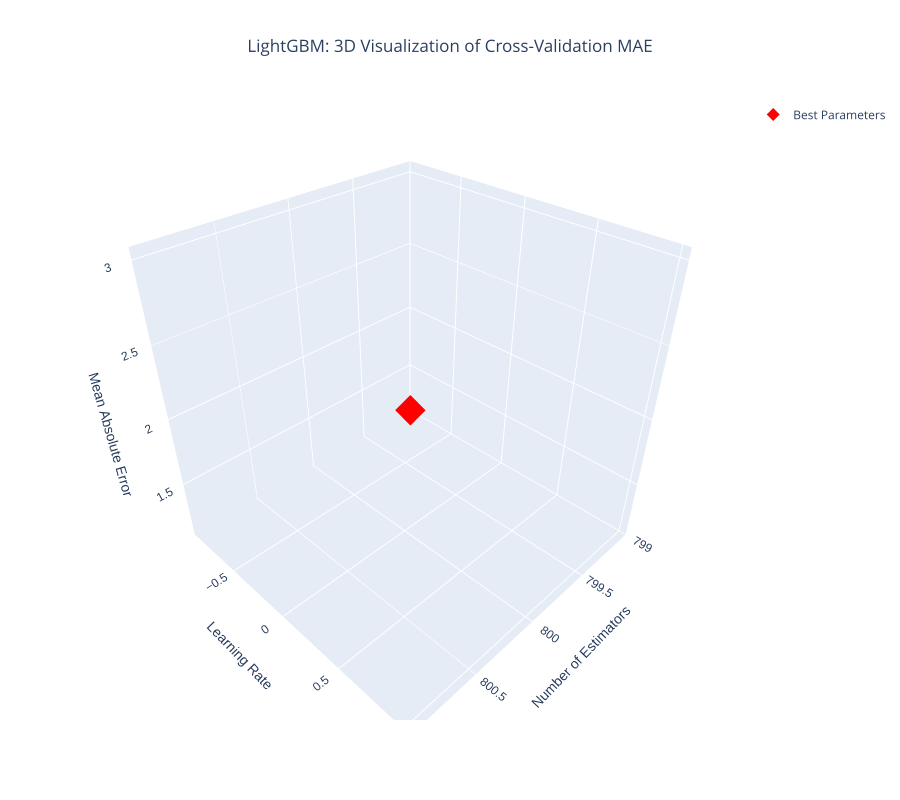

In [ ]:
fig = plot_3d_mae('LightGBM', lgbm_result_df, lgbm_best_params)
fig.show(renderer="svg", width=900, height=800)

MODEL: LightGBM
MAE: 2.15


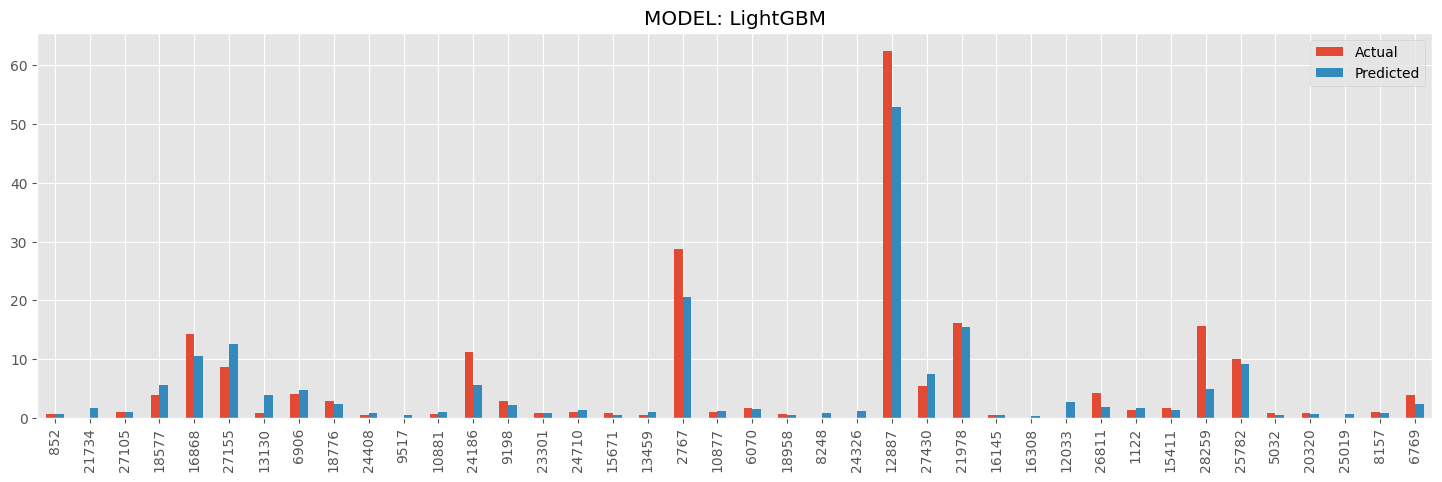

In [ ]:
model_name = 'LightGBM'

lgbm_metrics = get_metrics(model_name ,y_test, lgbm_y_pred)

plot_real_vs_pred(model_name, y_test, lgbm_y_pred)

## 5.6 Compare models' metrics

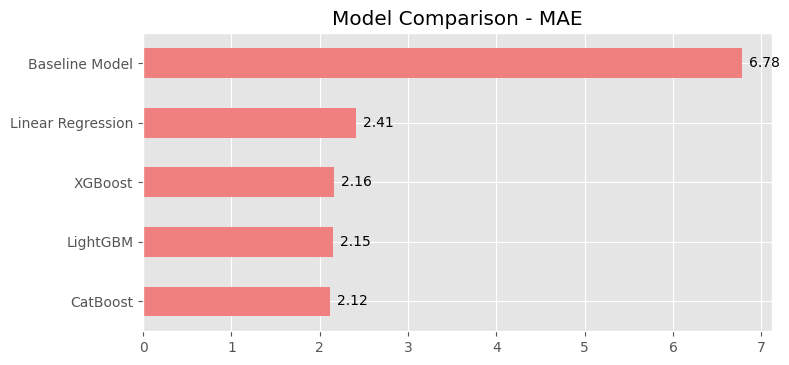

In [ ]:
compare_model_metrics([base_metrics, linear_metrics, xgb_metrics, cat_metrics, lgbm_metrics])

## 5.8 Relative importance of the features for the best model

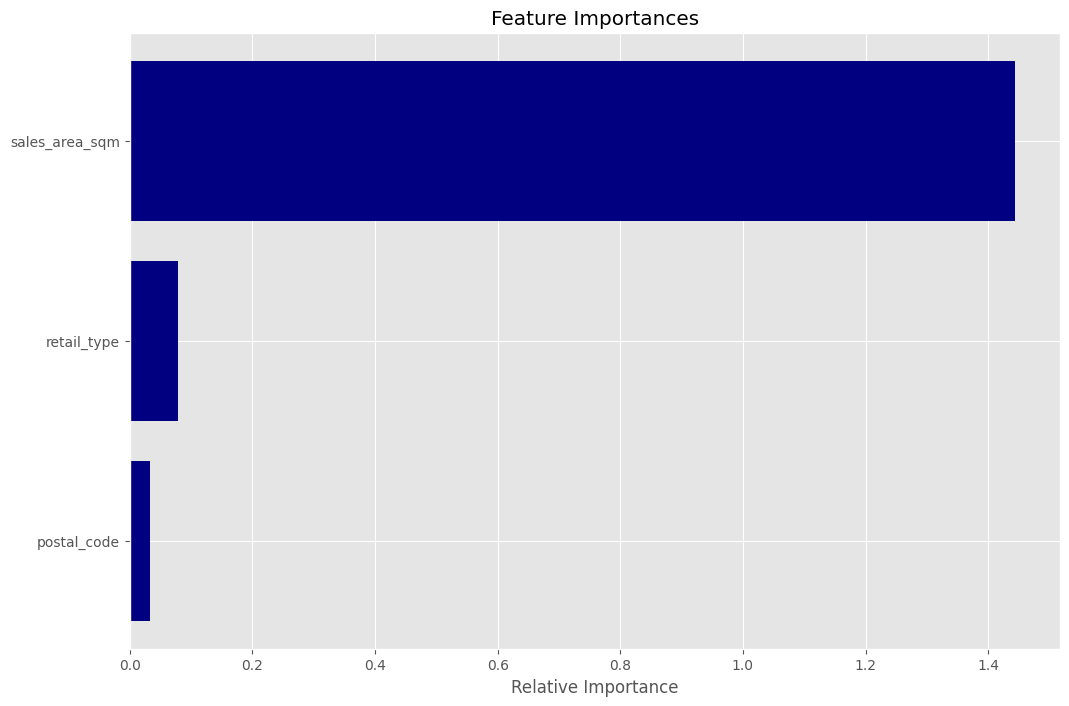

In [ ]:
result = permutation_importance(cat_best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Extract feature importances and their indices
importances = result.importances_mean
indices = np.argsort(importances)

# Get feature names sorted by importance
features = X_test.columns.tolist()
sorted_features = [features[i] for i in indices]

plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='navy', align='center')
plt.yticks(range(len(indices)), sorted_features)
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
X_test

,retail_type,store_name,contract_type,postal_code,city,sales_area_sqm,checkout_lanes,fuel_services,parking_spaces,drive_through_service,years_opened
14359,SDMP,LIDL,Intégré,56330,PLUVIGNER,825,63,Non,0,Non,18
11020,SDMP,LIDL,Intégré,41350,ST GERVAIS LA FORET,980,8,Non,0,Non,13
11251,Superette,CASINO SHOP,Intégré,42100,ST ETIENNE,169,1,Non,0,Non,21
21382,Supermarché,FRANPRIX,Intégré,75018,PARIS,664,7,Non,0,Non,52
20902,Superette,MONOP,Intégré,75010,PARIS,299,6,Non,0,Non,6
...,...,...,...,...,...,...,...,...,...,...,...
22673,Magasin Bio,BIOCOOP,Indépendant,77410,CLAYE SOUILLY,390,3,Non,0,Non,3
10901,Magasin Bio,BLOIS NATURE,Indépendant,41000,BLOIS,30,1,Non,0,Non,13
24217,Magasin Bio,LES COMPTOIRS DE LA BIO,Indépendant,82000,MONTAUBAN,600,3,Non,0,Non,7
3330,Superette,PANIER SYMPA,Indépendant,14000,CAEN,120,1,Non,0,Non,9


## 5.9 MAE comparison by retail type

           retail_type       MAE
0        Click & Drive  0.902256
1          Hypermarché  6.996712
2          Magasin Bio  0.486750
3  Petit Libre-Service  0.220094
4                 SDMP  1.366281
5            Superette  0.387206
6          Supermarché  1.750304


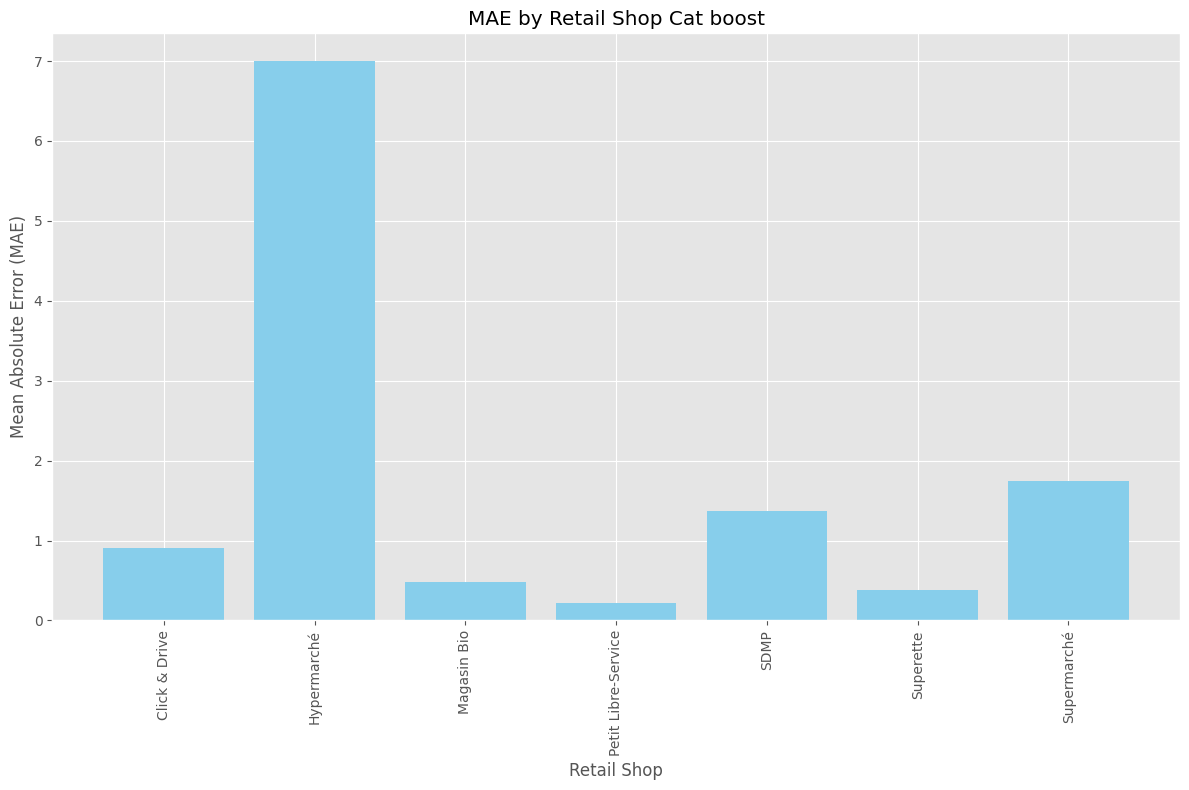

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

def get_metrics_by_shop(original_df, y_real, y_pred, retail_shop_column):
    df = original_df.copy()
    df['y_real'] = y_real
    df['y_pred'] = y_pred
    mae_by_shop = df.groupby(retail_shop_column).apply(lambda x: mean_absolute_error(x['y_real'], x['y_pred']))
    mae_by_shop_df = mae_by_shop.reset_index().rename(columns={0: 'MAE'})

    print(mae_by_shop_df)
    return mae_by_shop_df

def plot_mae_by_shop(mae_df):
    plt.figure(figsize=(12, 8))
    plt.bar(mae_df['retail_type'], mae_df['MAE'], color='skyblue')
    plt.xlabel('Retail Shop')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE by Retail Shop Cat boost')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Plotting the MAE by retail shop
test_with_predictions = X_test.copy()
test_with_predictions['y_real'] = y_test
test_with_predictions['y_pred'] = cat_y_pred
test_with_predictions['retail_type'] = df.loc[test_with_predictions.index, 'retail_type']

mae_by_shop_df = get_metrics_by_shop(test_with_predictions, test_with_predictions['y_real'], test_with_predictions['y_pred'], 'retail_type')
plot_mae_by_shop(mae_by_shop_df)

           retail_type        MAE
0        Click & Drive   1.018210
1          Hypermarché  10.150074
2          Magasin Bio   0.497000
3  Petit Libre-Service   0.245687
4                 SDMP   1.504743
5            Superette   0.377603
6          Supermarché   1.868114


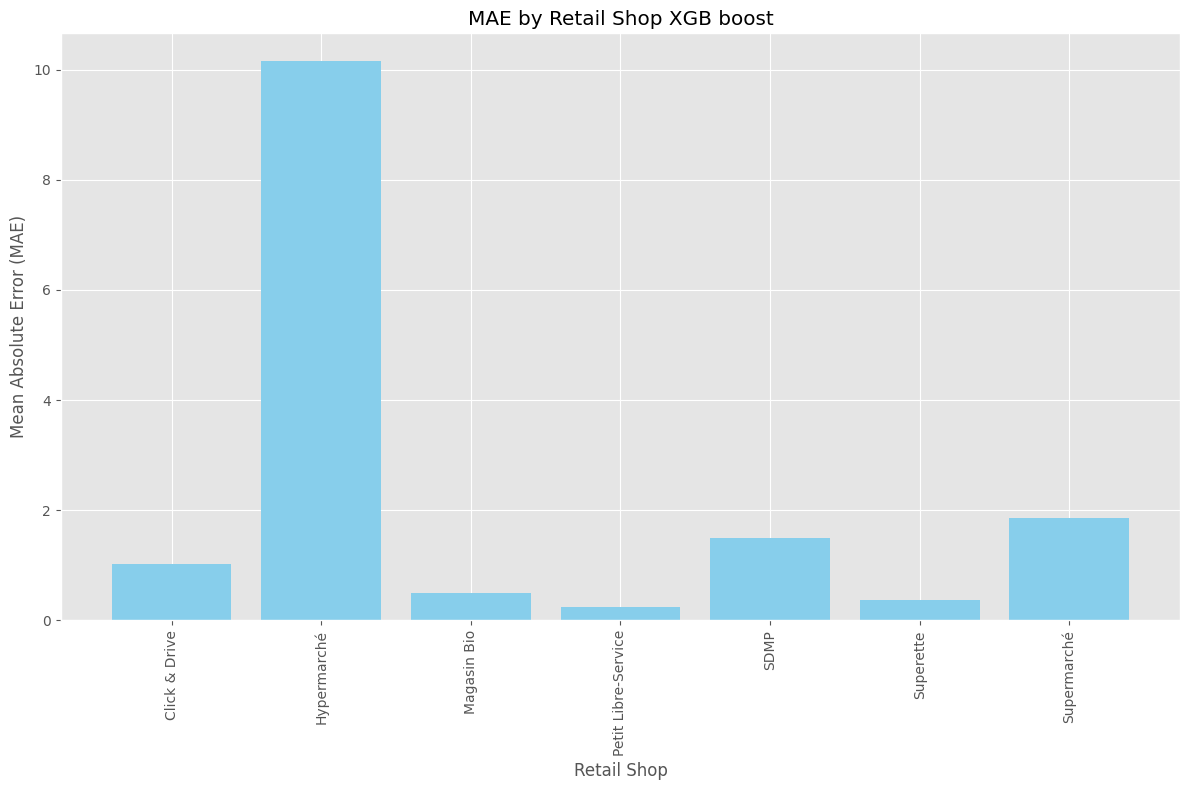

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

def get_metrics_by_shop(original_df, y_real, y_pred, retail_shop_column):
    df = original_df.copy()
    df['y_real'] = y_real
    df['y_pred'] = y_pred
    mae_by_shop = df.groupby(retail_shop_column).apply(lambda x: mean_absolute_error(x['y_real'], x['y_pred']))
    mae_by_shop_df = mae_by_shop.reset_index().rename(columns={0: 'MAE'})

    print(mae_by_shop_df)
    return mae_by_shop_df

def plot_mae_by_shop(mae_df):
    plt.figure(figsize=(12, 8))
    plt.bar(mae_df['retail_type'], mae_df['MAE'], color='skyblue')
    plt.xlabel('Retail Shop')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE by Retail Shop XGB boost')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

test_with_predictions = X_test.copy()
test_with_predictions['y_real'] = y_test
test_with_predictions['y_pred'] = xgb_y_pred
test_with_predictions['retail_type'] = df.loc[test_with_predictions.index, 'retail_type']

mae_by_shop_df = get_metrics_by_shop(test_with_predictions, test_with_predictions['y_real'], test_with_predictions['y_pred'], 'retail_type')
plot_mae_by_shop(mae_by_shop_df)

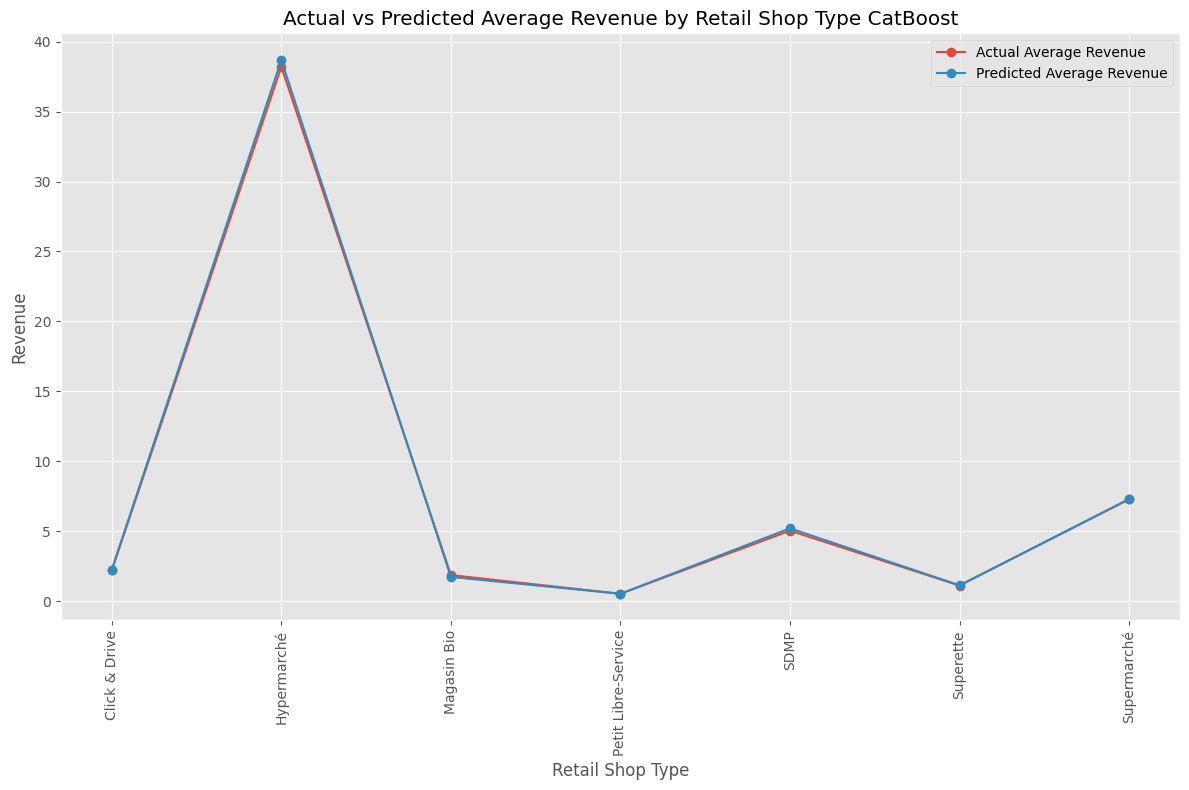

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def average_revenue_prediction(original_df, test_df, retail_shop_column, target_column):
    avg_revenue = test_df.groupby(retail_shop_column)[target_column].mean()
    avg_revenue_pred = test_df.groupby(retail_shop_column)['y_pred'].mean()
    return avg_revenue, avg_revenue_pred

def plot_actual_vs_predicted(avg_revenue, avg_revenue_pred, retail_shop_column):
    avg_revenue_df = avg_revenue.reset_index()
    avg_revenue_pred_df = avg_revenue_pred.reset_index()

    plt.figure(figsize=(12, 8))
    plt.plot(avg_revenue_df[retail_shop_column], avg_revenue_df["y_real"], marker='o', label='Actual Average Revenue')
    plt.plot(avg_revenue_pred_df[retail_shop_column], avg_revenue_pred_df['y_pred'], marker='o', label='Predicted Average Revenue')
    plt.xlabel('Retail Shop Type')
    plt.ylabel('Revenue')
    plt.title('Actual vs Predicted Average Revenue by Retail Shop Type CatBoost')
    plt.legend()
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

df_filtered = df.loc[y_test.index]

test_with_predictions = X_test.copy()
test_with_predictions['y_real'] = y_test
test_with_predictions['y_pred'] = cat_y_pred
test_with_predictions['retail_type'] = df_filtered['retail_type'].astype(str)

avg_revenue, avg_revenue_pred = average_revenue_prediction(test_with_predictions, test_with_predictions, 'retail_type', 'y_real')

plot_actual_vs_predicted(avg_revenue, avg_revenue_pred, 'retail_type')
